<a href="https://colab.research.google.com/github/harshaesmayil/data-analysis-using-pd/blob/main/movies_texol2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit

df=pd.read_csv('/content/movies.csv')

print("---------------- Shape of the dataframe ----------------")
print(df.shape)

---------------- Shape of the dataframe ----------------
(4803, 24)


In [12]:
print("---------------- Column info and datatype ----------------")
print(df.info())

---------------- Column info and datatype ----------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime      

In [13]:
print("---------------- Statistical Description ----------------")
print(df.describe())

---------------- Statistical Description ----------------
             index        budget             id   popularity       revenue  \
count  4803.000000  4.803000e+03    4803.000000  4803.000000  4.803000e+03   
mean   2401.000000  2.904504e+07   57165.484281    21.492301  8.226064e+07   
std    1386.651002  4.072239e+07   88694.614033    31.816650  1.628571e+08   
min       0.000000  0.000000e+00       5.000000     0.000000  0.000000e+00   
25%    1200.500000  7.900000e+05    9014.500000     4.668070  0.000000e+00   
50%    2401.000000  1.500000e+07   14629.000000    12.921594  1.917000e+07   
75%    3601.500000  4.000000e+07   58610.500000    28.313505  9.291719e+07   
max    4802.000000  3.800000e+08  459488.000000   875.581305  2.787965e+09   

           runtime  vote_average    vote_count  
count  4801.000000   4803.000000   4803.000000  
mean    106.875859      6.092172    690.217989  
std      22.611935      1.194612   1234.585891  
min       0.000000      0.000000      0.000

In [14]:
print("---------------- Missing value report ----------------")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0].sort_values(ascending=False))

---------------- Missing value report ----------------
homepage        3091
tagline          844
keywords         412
cast              43
director          30
genres            28
overview           3
runtime            2
release_date       1
dtype: int64


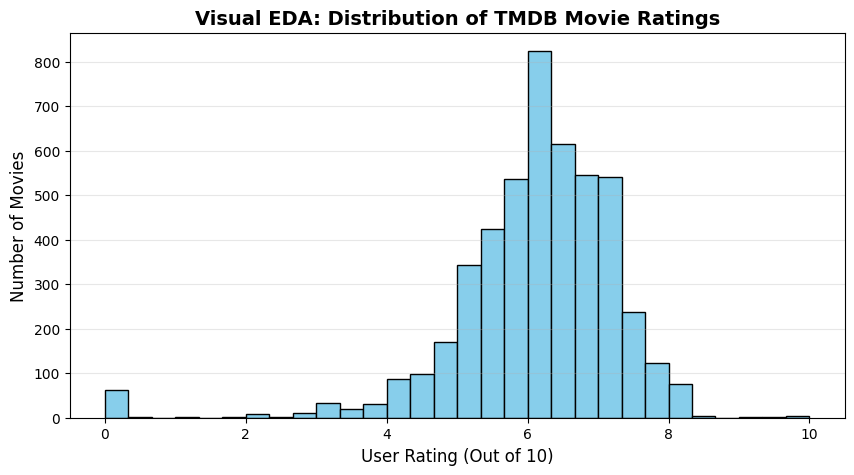

In [15]:
# matplotlib visual eda

plt.figure(figsize=(10, 5))

plt.hist(df['vote_average'].dropna(), bins=30, color='skyblue', edgecolor='black')

plt.title('Visual EDA: Distribution of TMDB Movie Ratings', fontsize=14, fontweight='bold')
plt.xlabel('User Rating (Out of 10)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [16]:
# new df stores cleaned df where the 2 columns that has too many null values is deleted
df_cleaned=df.drop(columns=['homepage', 'tagline'])

#in the column runtime, in places with blank data, median is filled, so no more blank space in runtime
runtime_median=df_cleaned['runtime'].median()
df_cleaned['runtime']=df_cleaned['runtime'].fillna(runtime_median)

print("Remaining missing values in runtime column:",df_cleaned['runtime'].isnull().sum())

Remaining missing values in runtime column: 0


In [21]:
#calculate lower and upper cut
Q1=df_cleaned['budget'].quantile(0.25)
Q3=df_cleaned['budget'].quantile(0.75)

#iqr - the mid 50%
IQR=Q3-Q1

#calculate the outliers
lower_fence=Q1*(1.5*IQR)
upper_fence=Q3*(1.5*IQR)

#caculate the outliers
outliers_df=df_cleaned[(df_cleaned['budget']>upper_fence) | (df_cleaned['budget']<lower_fence)]

print("Total num of budget outliers detected:",len(outliers_df))

Total num of budget outliers detected: 4803


In [22]:
#chatgpt code for outlier calculation:

# 1. Create a temporary slice of data with only real, non-zero budgets
real_budgets = df_cleaned[df_cleaned['budget'] > 0]['budget']

# 2. Calculate our cuts using ONLY those real budgets
Q1 = real_budgets.quantile(0.25)
Q3 = real_budgets.quantile(0.75)
IQR = Q3 - Q1

# 3. Re-calculate our upper safety fence
upper_fence = Q3 + (1.5 * IQR)
lower_fence = Q1 - (1.5 * IQR)

# 4. Count how many of our real movies actually cross that high fence
outliers_df = df_cleaned[df_cleaned['budget'] > upper_fence]

print("Real number of budget blockbusters/outliers detected:", len(outliers_df))
print("The boundary for an outlier budget was set at: $", round(upper_fence, 2))

Real number of budget blockbusters/outliers detected: 245
The boundary for an outlier budget was set at: $ 113000000.0


In [29]:
#categorical encoding
#this command creates sep columns and removes redundant columns

df_encoded=pd.get_dummies(df_cleaned,columns=['status'],drop_first=True)
print("Newly encoded columns:")

#printing the columns with the word status
status_columns = [col for col in df_encoded.columns if 'status' in col]
df_encoded[status_columns].head()

Newly encoded columns:


,status_Released,status_Rumored
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False


In [31]:
#scaling strategy
#scaling means we are changing the range of all data so that theyre all similar without losing the meaning

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

num_columns=['budget','revenue','runtime','popularity','vote_count']
df_encoded[num_columns]=scaler.fit_transform(df_encoded[num_columns])
df_encoded[num_columns].head(5)

,budget,revenue,runtime,popularity,vote_count
0,5.107181,16.615709,2.438652,4.053183,8.999729
1,6.654402,5.396331,2.748318,3.696258,3.086200
2,5.303653,4.903054,1.819320,2.699638,3.058657
3,5.426449,6.157440,2.571366,2.854798,6.817394
4,5.672039,1.239734,1.111513,0.705198,1.161467


In [ ]:
#the hypothesis notes are based on the describe keyword in cell 3. the notes are in readme file of github repo



> Add blockquote

